# Optimization under uncertainty: searching the decision space

_What if we pumped differently?_

Everything up to here has answered a single question about a single plan: given how the supply well (`wellopt`) is scheduled to run, *how much* sulfate will the supplied water carry, and how sure are we? The history match sharpened that forecast distribution; the dataworth notebook asked which extra measurements would sharpen it further. None of it told us what to *do*.

This notebook closes the loop. The supply well is not a fixed object: we can throttle its extraction rate and we can choose *when* in the supply period to switch it on. Those are the levers a manager actually holds. We pose them as **decision variables** and search for the trade-off between supplying more water and keeping peak sulfate low — a bi-objective **optimization under uncertainty**.

Where this sits in the sequence:

- [`../part1_05_dsi_basics/dizon_dsi_basics.ipynb`](../part1_05_dsi_basics/dizon_dsi_basics.ipynb) trained, validated and conditioned the DSI emulator — the machinery and the discipline ("never trust an emulator you have not tested") carry straight into this notebook.
- [`../part1_06_full_model_check/`](../part1_06_full_model_check/) validated the DSI posterior against a genuine full-model history match.
- [`../part1_07_dataworth/`](../part1_07_dataworth/) used the emulator to value held-back *data*.
- This notebook is the last in the sequence: it uses the same emulation-first thinking to value held-back *decisions*.

### Admin

We lean on the vendored dependency trees (`flopy`, `pyemu`) that ship with this repository — in particular the `rhugman/pyemu@feat_dsivc` branch, which carries the `DSIVC` ("DSI variable control") workflow we discuss below. As elsewhere in the series, `herebedragons` (imported as `hbd`) holds the shared plotting and bookkeeping helpers, and every workspace this notebook creates lives *inside this notebook's own directory* and is gitignored.

One prebaked artifact is doing the heavy lifting here: the **decision-variable training sweep** (`../../prebaked/dsivc_sweep/`). What it is, why it had to be run, and what it cost are spelled out in [the sweep section](#The-training-sweep:-why-plain-DSI-is-not-enough) below.

In [1]:
import os
import sys
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import flopy
import pyemu

warnings.filterwarnings("ignore")

sys.path.insert(0, "..")
import herebedragons as hbd

Confirm we are running the vendored dependencies, and that this `pyemu` carries the DSIVC workflow we will discuss (it lives only on the `feat_dsivc` branch we vendor):

In [2]:
assert "dependencies" in flopy.__file__, flopy.__file__
assert "dependencies" in pyemu.__file__, pyemu.__file__
from pyemu.emulators import DSI, DSIVC   # DSIVC exists only on rhugman/pyemu@feat_dsivc
assert hasattr(pyemu.emulators, "DSIVC"), (
    "this pyemu has no DSIVC; refresh dependencies/pyemu from rhugman/pyemu@feat_dsivc"
)
print("vendored pyemu with DSIVC present")

vendored pyemu with DSIVC present


**Prerequisite check.** This notebook consumes one prebaked product: the decision-variable training sweep. It ships as two files in `../../prebaked/dsivc_sweep/`:

- `sweep_obs_ensemble.jcb` — the model outputs (the curated conditioning + forecast observations) for every surviving sweep run, loaded against the thinned control file `../../prebaked/pest.pst`;
- `sweep_dvs.csv` — the decision-variable values (rate multiplier, switch-on day) that produced each run.

If the sweep is missing, the cell below stops with a pointer to the maintainer script that bakes it.

In [3]:
prebaked = Path("..") / ".." / "prebaked"
sweep_dir = prebaked / "dsivc_sweep"
sweep_oe_path = sweep_dir / "sweep_obs_ensemble.jcb"
sweep_dv_path = sweep_dir / "sweep_dvs.csv"
pst_path = prebaked / "pest.pst"

for p in (sweep_oe_path, sweep_dv_path, pst_path):
    if not p.exists():
        raise Exception(
            f"required prebaked artifact not found: {p}\n"
            "the DSIVC training sweep is baked by etc/run_dsivc_sweep.py followed by "
            "etc/make_prebaked.py dsivc-sweep --source master_sweep")
print("prebaked sweep artifacts found")

prebaked sweep artifacts found


## The decision problem

The decision is recast once, canonically, here. Two **decision variables** describe how the supply well is operated:

- a **rate multiplier** on the base supply-well extraction rate — how hard we pump, drawn across `[0.25, 2.0]`; and
- a **switch-on day** within the supply period — *when* we start, drawn across `[308, 500]` d. The well activates at the first stress period whose start is on or after the switch day (the model schedules pumping at stress-period granularity; the continuous switch-day is a relaxation the search smooths over).

Two **objectives** describe what we care about:

- **maximize the volume of water supplied** over the supply period, and
- **minimize P95(peak SO₄)** — the 95th percentile, across the parameter-field uncertainty, of the peak sulfate concentration at the supply well.

These *might* pull against each other — pumping harder and earlier supplies more water, and the intuition is that it also drags the redox front toward the well faster, raising peak sulfate. Whether that intuition survives contact with the sweep is one of the things this notebook settles. There is no single best plan; there is a *front* of non-dominated trade-offs, and we read it honestly.

The objectives are **minimize-native**: lower P95(peak SO₄), more volume. No threshold is baked into the search, and none is needed — the front *is* the answer. Choosing P95 (rather than the mean) is the decision-support move: the manager is not asked "what is the expected peak?" but "how much water can I promise, and how high might the sulfate run while I do?" The percentile *is* the risk appetite, stated out loud — treatment capacity is sized to it.

A contractual trigger, if one exists, is an **illustrative lens** drawn across the same front, not a second analysis: with a 90 mg/L supply-contract trigger on the sulfate axis, the *reliable* (chance-constrained) reading is simply the segment of the front below the line — plans holding P95(peak SO₄) under 90 mg/L. (The EU drinking-water standard of 250 mg/L is comfortably met across the whole front; cost, not compliance, drives this decision.)

A unit note worth stating once. The forecast obs (`welopt-ly*`, variable `so4`) are carried in **mol/L**, the way the transport model writes them. A contractual trigger such as 90 mg/L is in mg/L. The conversion uses the molar mass of SO₄ (≈96.06 g/mol), so 90 mg/L ≈ `90e-3 / 96.06` mol/L. We carry the ensemble in mg/L for display and convert the trigger the same way, so the figures speak one language.

In [4]:
# supply-period bookkeeping (constants only; no model run).
SO4_MW = 96.06                      # g/mol
CONTRACT_TRIGGER_MGL = 90.0         # illustrative supply-contract trigger (lens only)

SUPPLY_START, SUPPLY_END = 308.0, 728.0   # supply period (days); the forecast lives here
DECISION_DATE = 252.0                      # decision committed ~8 weeks before switch-on

# decision-variable bounds (the sweep was drawn across exactly these)
RM_LO, RM_HI = 0.25, 2.0            # rate multiplier
SW_LO, SW_HI = 308.0, 500.0         # switch-on day

# the supply stress periods and their start days, read from the sweep design
# (run_dsivc_sweep.py): SP index -> start day. The last SP ends at SUPPLY_END.
SUPPLY_SP_STARTS = {22: 308, 23: 336, 24: 364, 25: 392, 26: 420, 27: 455, 28: 490,
                    29: 518, 30: 546, 31: 574, 32: 609, 33: 644, 34: 672, 35: 700}

# the supply well's base extraction rates (three screens), m3/d:
BASE_RATES = {"welopt-ly1": 1300.0, "welopt-ly3": 300.0, "welopt-ly5": 300.0}
BASE_RATE_TOTAL = sum(BASE_RATES.values())   # 1900 m3/d at the canonical rate multiplier

print(f"90 mg/L  ->  {CONTRACT_TRIGGER_MGL * 1e-3 / SO4_MW:.4e} mol/L")
print(f"supply window {SUPPLY_START:.0f}-{SUPPLY_END:.0f} d; "
      f"base supply rate {BASE_RATE_TOTAL:.0f} m3/d over {len(BASE_RATES)} screens")

90 mg/L  ->  9.3691e-04 mol/L
supply window 308-728 d; base supply rate 1900 m3/d over 3 screens


## The training sweep: why plain DSI is not enough

Here is the catch, and it is the whole reason this notebook needs its own prebaked artifact.

DSI is an **observation-space emulator**. In `part1_05` it learned the joint distribution of the model outputs — the breakthrough series at every site and species, including the supply-well sulfate forecast — *as produced by the prior parameter ensemble running one fixed supply-well schedule*. Conditioning it with PESTPP-IES slid that distribution toward the data. At no point did that emulator see a run where the pump rate or switch-on day was different, because no such run exists in the prior Monte Carlo. The decision variables are **inputs to the forward model**, not outputs the emulator ever observed.

So the `part1_05` emulator cannot answer "what if we pumped differently?" by interpolation. It has no axis for the decision. Asking it to extrapolate a pumping change it never saw would be exactly the kind of unvalidated emulator use the [fidelity-check beat](../part1_05_dsi_basics/dizon_dsi_basics.ipynb) warned against.

The fix is to give the emulator that axis on purpose. **Coverage of decision space is designed, not inherited.** A dedicated **training sweep** takes the history-matched *posterior* parameter fields (from the full-model IES of `part1_06`) and, for each one, re-samples the decision variables across their bounds and runs the full model. Each run is a (posterior field, pumping plan) pair. The sweep thus spans both the residual parameter uncertainty *and* the decision space — and the decision variables now appear as values attached to each run, alongside the outputs.

That is what `../../prebaked/dsivc_sweep/` holds. Let us load it and read the provenance off the sidecar:

In [5]:
import json
with open(sweep_dir / "dsivc_sweep.json") as f:
    prov = json.load(f)
for k in ("source_dir", "n_realisations", "thinned_to_n_obs", "cost_note", "notes"):
    print(f"{k}: {prov[k]}")

source_dir: master_sweep
n_realisations: 133
thinned_to_n_obs: 29434
cost_note: ~6 min per forward model run; full prior MC is ~201 runs
notes: posterior parameter fields (full-model IES iteration 1) x one decision-variable draw each: dv-rate-mult U[0.25,2], dv-switch-day U[308,500] (well activates at first SP start >= switch day); base row = canonical operation (1.0, 308). Curated-set control file: prebaked/pest.pst (no dv params -- part1_08 attaches them).


In [6]:
# the control file for the curated obs set, and the sweep obs ensemble against it.
pst = pyemu.Pst(str(pst_path))
pst.try_parse_name_metadata()
oe = pyemu.ObservationEnsemble.from_binary(pst=pst, filename=str(sweep_oe_path))
sweep_obs = oe._df.copy()
sweep_obs.index = sweep_obs.index.astype(str)

# the decision-variable values that produced each run (join on the run index)
dvs = pd.read_csv(sweep_dv_path, index_col=0)
dvs.index = dvs.index.astype(str)

print(f"sweep obs ensemble: {sweep_obs.shape[0]} surviving runs x {sweep_obs.shape[1]} obs")
print(f"decision-variable table: {dvs.shape[0]} rows (incl. failed runs and 'base')")
print(f"dv columns: {list(dvs.columns)}")

sweep obs ensemble: 133 surviving runs x 29434 obs
decision-variable table: 160 rows (incl. failed runs and 'base')
dv columns: ['dv-rate-mult', 'dv-switch-day']


**Attrition, told honestly.** The sweep was drawn as one decision-variable sample per posterior field — 160 runs in all, including the canonical `base` operation (rate multiplier 1.0, switch-on day 308). Not all of them completed: a reactive-transport model pushed to extreme pumping rates can fail to converge, and some did. The decision-variable table carries every attempted run; the obs ensemble carries only the survivors. We line them up and see how many we actually have to work with:

In [7]:
attempted = dvs.shape[0]
survived = sweep_obs.shape[0]
failed = attempted - survived
# the runs we can actually use: surviving obs that also have dv values, base excluded
run_ids = [i for i in sweep_obs.index if i in dvs.index and i != "base"]
has_base = "base" in sweep_obs.index
print(f"{attempted} runs attempted, {survived} survived "
      f"({failed} failed to converge -- extreme pumping is hard on a reactive model)")
print(f"usable parameter-field x decision draws: {len(run_ids)} "
      f"(plus the canonical 'base' run: {'present' if has_base else 'MISSING'})")

160 runs attempted, 133 survived (27 failed to converge -- extreme pumping is hard on a reactive model)
usable parameter-field x decision draws: 132 (plus the canonical 'base' run: present)


## The forecast and the response surface

The canonical forecast is **peak SO₄ at the supply well during the supply period** — the maximum over all three supply-well screens (`welopt-ly1`, `welopt-ly3`, `welopt-ly5`) and over the supply-window times, the same definition used everywhere in this series. The thinned control file stages exactly these observations as the `forecast` group, so we read them straight off it (no string-matching guesswork):

In [8]:
obs = pst.observation_data
fore = obs.loc[obs.obgnme == "forecast"]
fore_cols = [c for c in fore.obsnme if c in sweep_obs.columns]
print(f"forecast group: {len(fore_cols)} obs "
      f"(screens {sorted(fore.obsid.unique())}, variable {sorted(fore.variable.unique())}, "
      f"times {pd.to_numeric(fore.time).min():.0f}-{pd.to_numeric(fore.time).max():.0f} d)")

def peak_so4_mgl(ensemble):
    """Peak supply-period SO4 (mg/L), max over all supply-well screens, per run."""
    cols = [c for c in fore_cols if c in ensemble.columns]
    return ensemble.loc[:, cols].max(axis=1) * 1000.0 * SO4_MW   # mol/L -> mg/L

peak = peak_so4_mgl(sweep_obs)
print(f"\npeak SO4 across the sweep (mg/L): "
      f"min={peak.loc[run_ids].min():.0f}  median={peak.loc[run_ids].median():.0f}  "
      f"P95={peak.loc[run_ids].quantile(0.95):.0f}  max={peak.loc[run_ids].max():.0f}")

forecast group: 1263 obs (screens ['welopt-ly1', 'welopt-ly3', 'welopt-ly5'], variable ['so4'], times 308-728 d)

peak SO4 across the sweep (mg/L): min=56  median=84  P95=98  max=99


Each sweep run is one parameter field crossed with one pumping plan, so plotting peak SO₄ against each decision variable *is* the response surface — the thing the `part1_05` emulator could never have shown us. We colour each scatter by the *other* decision variable, so the two levers can be read at once:

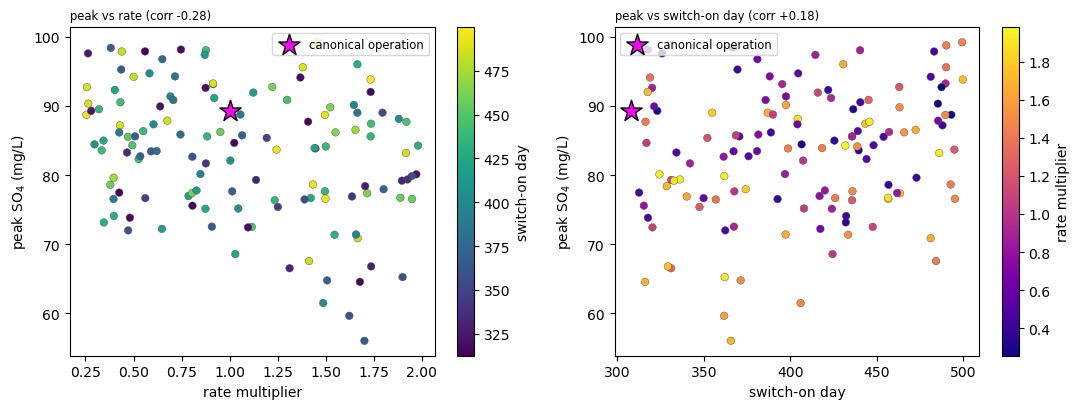

In [9]:
pk = peak.loc[run_ids].values
rm = dvs.loc[run_ids, "dv-rate-mult"].values
sw = dvs.loc[run_ids, "dv-switch-day"].values

# the canonical 'base' operation, for reference points
base_pk = float(peak.loc["base"]) if has_base else np.nan
base_rm, base_sw = float(dvs.loc["base", "dv-rate-mult"]), float(dvs.loc["base", "dv-switch-day"])

corr_rm = np.corrcoef(pk, rm)[0, 1]
corr_sw = np.corrcoef(pk, sw)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sc0 = axes[0].scatter(rm, pk, c=sw, cmap="viridis", s=30, edgecolor="0.3", lw=0.3)
axes[0].scatter([base_rm], [base_pk], marker="*", s=260, color="fuchsia",
                edgecolor="k", zorder=5, label="canonical operation")
axes[0].set_xlabel("rate multiplier"); axes[0].set_ylabel("peak SO$_4$ (mg/L)")
axes[0].set_title(f"peak vs rate (corr {corr_rm:+.2f})", loc="left", fontsize="small")
axes[0].legend(fontsize="small", loc="upper right")
fig.colorbar(sc0, ax=axes[0], label="switch-on day")

sc1 = axes[1].scatter(sw, pk, c=rm, cmap="plasma", s=30, edgecolor="0.3", lw=0.3)
axes[1].scatter([base_sw], [base_pk], marker="*", s=260, color="fuchsia",
                edgecolor="k", zorder=5, label="canonical operation")
axes[1].set_xlabel("switch-on day"); axes[1].set_ylabel("peak SO$_4$ (mg/L)")
axes[1].set_title(f"peak vs switch-on day (corr {corr_sw:+.2f})", loc="left", fontsize="small")
axes[1].legend(fontsize="small", loc="upper left")
fig.colorbar(sc1, ax=axes[1], label="rate multiplier")
fig.tight_layout()

Read the two panels together. The signs are computed above, not asserted:

- **Pumping harder lowers the peak.** The correlation of peak SO₄ with the rate multiplier is negative. The mechanism is physical: a stronger extraction induces more capture of the relatively fresh injectate, diluting the redox-front sulfate that reaches the well. This is the *opposite* of the naive "pump harder, pull the front in faster" intuition — and it is exactly the kind of counter-intuitive coupling that only a sweep over the real model can reveal.
- **Delaying switch-on raises the peak.** The correlation with switch-on day is positive: the longer the front is left to develop before the supply well draws, the more sulfate has accumulated in the zone it eventually captures.

Both effects are modest against the scatter — the *parameter-field* uncertainty (the vertical spread at any fixed decision) is large compared to what the decision itself moves. That is itself a finding, and it shapes the front below.

## How DSIVC works, and the route we take here

The vendored `pyemu` carries a purpose-built workflow for exactly this problem: **DSIVC**, "DSI variable control". Its central idea is elegant — treat the decision variables as **observations** in DSI-world (columns of the training ensemble a manager can *control* rather than merely observe), fit a DSI emulator on `[model outputs + decision-variable columns]`, then wrap an outer PESTPP-MOU optimizer around it. Evaluating one candidate plan becomes a nested loop: the outer optimizer proposes a plan, those values are injected into the inner `dsi.pst` as high-weight zero-noise observation targets ("condition the emulator on the world where we pump *this* way"), a nested PESTPP-IES conditioning runs against the emulator in run-storage mode (`pestpp-ies dsi.pst /e`), and the conditioned posterior — the "stack" — is summarized into per-output percentiles (the "stack stats") that become the outer problem's objectives and constraints.

DSIVC is the right tool when the decision space is large, the objectives are many, or the inner conditioning genuinely tightens the forecast for each candidate. **Here we take the simpler, more transparent route, and we say so plainly.** Two reasons:

1. **The shipped artifact does not fit the DSIVC constructor as-is.** `DSIVC` requires the observation ensemble's columns to *equal* the inner `dsi.pst` observation set, decision variables included. Our sweep ships the decision-variable values in a separate table (`sweep_dvs.csv`), not as obs columns — using DSIVC would mean appending them as columns, re-fitting DSI on the sweep, re-preparing a run-storage template, and running a nested PESTPP-MOU. That is a great deal of machinery to wrap around a **two**-decision-variable problem.
2. **With 133 runs over a 2-D decision space, the response surface is *already sampled*.** We do not need to emulate a surface we can see directly. A dense grid over the two decision variables, with the P95 at each grid point estimated by a **local weighted ensemble** of nearby sweep runs, is honest, fast, and — most important for a teaching notebook — fully transparent. Every number on the front below traces back to runs you can point at on the scatter above.

So: we keep DSIVC in view as the production-grade path, and we solve *this* problem the way its size deserves.

## Objective 1: volume supplied (deterministic in the decisions)

Volume is the easy objective: it does not depend on the uncertain parameter fields at all, only on the two decisions. The supply well runs from its switch-on stress period to the end of the supply window; over each active stress period it extracts the base rate times the rate multiplier. Switching on later simply drops the leading stress periods.

We read the stress-period lengths off the design (consecutive start days; the last period ends at day 728) and write volume as a closed form:

In [10]:
_starts = sorted(SUPPLY_SP_STARTS.values())
SP_LENGTHS = {s: (_starts[i + 1] if i + 1 < len(_starts) else SUPPLY_END) - s
              for i, s in enumerate(_starts)}
assert abs(sum(SP_LENGTHS.values()) - (SUPPLY_END - SUPPLY_START)) < 1e-6

def volume_supplied(rate_mult, switch_day):
    """m3 supplied = sum over supply SPs with start >= switch_day of
    (SP length * total base rate * rate_mult). The well activates at the first
    SP whose start is on or after switch_day."""
    return sum(L * BASE_RATE_TOTAL * rate_mult
               for s, L in SP_LENGTHS.items() if s >= switch_day)

base_volume = volume_supplied(1.0, SUPPLY_START)
print(f"supply window total length: {sum(SP_LENGTHS.values()):.0f} d")
print(f"canonical operation (rate 1.0, switch {SUPPLY_START:.0f}): "
      f"{base_volume:,.0f} m3 supplied")
print(f"maximum (rate {RM_HI}, switch {SUPPLY_START:.0f}): "
      f"{volume_supplied(RM_HI, SUPPLY_START):,.0f} m3")

supply window total length: 420 d
canonical operation (rate 1.0, switch 308): 798,000 m3 supplied
maximum (rate 2.0, switch 308): 1,596,000 m3


## Objective 2: P95(peak SO₄), by local weighted ensemble

For any candidate plan `(rate multiplier, switch-on day)`, we want the P95 of peak SO₄ *across the parameter-field uncertainty at that plan*. We do not have runs at exactly that plan, but we have 133 runs scattered nearby. The estimator is a **kernel-weighted percentile**: weight every sweep run by its proximity to the candidate in (normalised) decision space with a Gaussian kernel, then take the weighted 95th percentile of those runs' peak SO₄.

This is a standard nonparametric (Nadaraya–Watson-style) local estimator, applied to a quantile instead of a mean. The bandwidth is the one judgment call: too small and each grid point leans on a handful of runs (a noisy P95); too wide and the estimate washes out the decision dependence into the global P95. We pick a bandwidth that keeps a healthy *effective sample size* at every grid point and report that ESS so the reader can see the estimator is not running on fumes.

In [11]:
# normalise decisions to the unit square using their sampled bounds
def _norm(rate_mult, switch_day):
    return ((rate_mult - RM_LO) / (RM_HI - RM_LO),
            (switch_day - SW_LO) / (SW_HI - SW_LO))

rmn, swn = _norm(rm, sw)   # the sweep runs in normalised decision space

def weighted_quantile(values, q, weights):
    order = np.argsort(values)
    v = values[order]; w = weights[order]
    cum = np.cumsum(w) - 0.5 * w
    cum /= w.sum()
    return np.interp(q, cum, v)

BANDWIDTH = 0.12   # in normalised decision units (judgment call; see ESS below)

def local_p95(rate_mult, switch_day, q=0.95):
    rn, sn = _norm(rate_mult, switch_day)
    d2 = (rmn - rn) ** 2 + (swn - sn) ** 2
    w = np.exp(-0.5 * d2 / BANDWIDTH ** 2)
    ess = w.sum() ** 2 / (w ** 2).sum()   # Kish effective sample size
    return weighted_quantile(pk, q, w), weighted_quantile(pk, 0.5, w), ess

Lay down a dense grid over the two decisions and evaluate volume and the local-ensemble P95 (and median, for context) at every node:

In [12]:
NG = 45
rate_grid = np.linspace(RM_LO, RM_HI, NG)
switch_grid = np.linspace(SW_LO, SW_HI, NG)

rows = []
for r in rate_grid:
    for s in switch_grid:
        p95, p50, ess = local_p95(r, s)
        rows.append((r, s, volume_supplied(r, s), p95, p50, ess))
grid = pd.DataFrame(rows, columns=["rate", "switch", "volume", "p95", "p50", "ess"])

print(f"{len(grid)} grid points")
print(f"effective sample size per point: median {grid.ess.median():.0f}, "
      f"min {grid.ess.min():.0f} (of {len(run_ids)} sweep runs)")
print(f"local P95(peak SO4) across the grid: {grid.p95.min():.0f}-{grid.p95.max():.0f} mg/L")

2025 grid points
effective sample size per point: median 18, min 6 (of 132 sweep runs)
local P95(peak SO4) across the grid: 89-99 mg/L


Before the front, the P95 surface itself — the risk-relevant quantity, mapped over the decision space. Overlay the sweep runs so the reader can see the estimator is interpolating among real runs, not inventing structure:

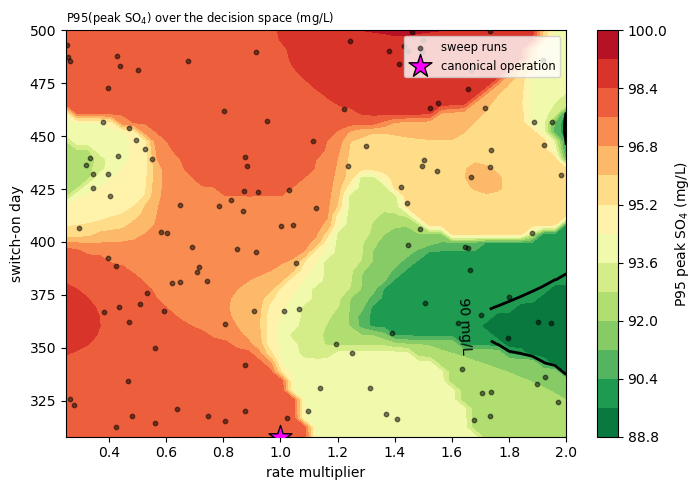

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 5))
P = grid.pivot(index="switch", columns="rate", values="p95")
cf = ax.contourf(P.columns.values, P.index.values, P.values, levels=14, cmap="RdYlGn_r")
cs = ax.contour(P.columns.values, P.index.values, P.values,
                levels=[CONTRACT_TRIGGER_MGL], colors="k", linewidths=2)
ax.clabel(cs, fmt="%.0f mg/L")
ax.scatter(rm, sw, c="k", s=10, alpha=0.5, label="sweep runs")
ax.scatter([base_rm], [base_sw], marker="*", s=300, color="fuchsia",
           edgecolor="k", zorder=5, label="canonical operation")
ax.set_xlabel("rate multiplier"); ax.set_ylabel("switch-on day")
ax.set_title("P95(peak SO$_4$) over the decision space (mg/L)", loc="left", fontsize="small")
ax.legend(fontsize="small", loc="upper right")
fig.colorbar(cf, ax=ax, label="P95 peak SO$_4$ (mg/L)")
fig.tight_layout()

## The Pareto front

A plan is **non-dominated** if no other plan supplies at least as much water *and* holds a lower-or-equal P95. The set of non-dominated grid points is the trade-off front. We extract it, plot it, mark the canonical operation, and draw the 90 mg/L contractual lens across it:

In [14]:
def pareto_front(volume, p95):
    """indices of non-dominated points: maximize volume, minimize p95."""
    order = np.argsort(-volume)        # most volume first
    keep = []; best_p95 = np.inf
    for i in order:
        if p95[i] < best_p95 - 1e-9:   # strictly better on the minimized objective
            keep.append(i); best_p95 = p95[i]
    return sorted(keep, key=lambda i: volume[i])

fi = pareto_front(grid.volume.values, grid.p95.values)
front = grid.iloc[fi].reset_index(drop=True)
print(f"Pareto front: {len(front)} non-dominated plans")
print(f"  volume spans {front.volume.min():,.0f} - {front.volume.max():,.0f} m3")
print(f"  P95 spans   {front.p95.min():.1f} - {front.p95.max():.1f} mg/L")
print(f"  rate multiplier on the front: {front.rate.min():.2f} - {front.rate.max():.2f}")
print(f"  switch-on day on the front:   {front.switch.min():.0f} - {front.switch.max():.0f}")

Pareto front: 9 non-dominated plans
  volume spans 1,383,200 - 1,596,000 m3
  P95 spans   89.2 - 92.1 mg/L
  rate multiplier on the front: 2.00 - 2.00
  switch-on day on the front:   308 - 360


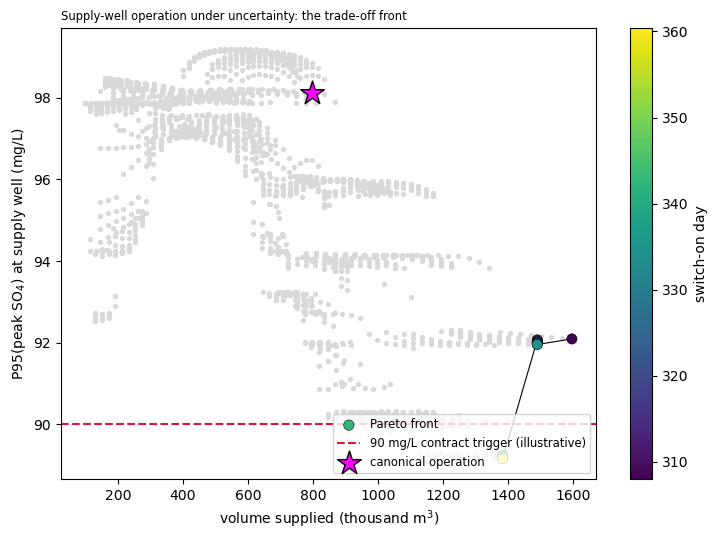

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
# the full cloud of evaluated plans, faint
ax.scatter(grid.volume / 1e3, grid.p95, c="0.85", s=8, zorder=1)
# the front, coloured by switch-on day (the lever that actually trades off)
sc = ax.scatter(front.volume / 1e3, front.p95, c=front.switch, cmap="viridis",
                s=55, edgecolor="k", lw=0.4, zorder=3, label="Pareto front")
ax.plot(front.volume / 1e3, front.p95, "k-", lw=0.8, zorder=2)
# the 90 mg/L contractual lens
ax.axhline(CONTRACT_TRIGGER_MGL, color="crimson", ls="--", lw=1.5, zorder=2,
           label=f"{CONTRACT_TRIGGER_MGL:.0f} mg/L contract trigger (illustrative)")
# canonical operation
base_p95, _, _ = local_p95(base_rm, base_sw)
ax.scatter([base_volume / 1e3], [base_p95], marker="*", s=320, color="fuchsia",
           edgecolor="k", zorder=5, label="canonical operation")
ax.set_xlabel("volume supplied (thousand m$^3$)")
ax.set_ylabel("P95(peak SO$_4$) at supply well (mg/L)")
ax.set_title("Supply-well operation under uncertainty: the trade-off front",
             loc="left", fontsize="small")
fig.colorbar(sc, ax=ax, label="switch-on day")
ax.legend(fontsize="small", loc="lower right")
fig.tight_layout()

### Reading the front honestly

The shape of this front is the lesson, and it is not the textbook diagonal:

- **The rate multiplier is not a trade-off — it is a free lunch.** Pumping harder both supplies more water *and* lowers peak SO₄ (the induced-dilution effect from the response surface). So every point on the front sits at or near the maximum rate multiplier: there is no reason to pump gently. The decision that genuinely trades off is the **switch-on day**, which is why the front is coloured by it.
- **The trade-off the front *does* show is weak.** Across its whole length the P95 moves only a few mg/L while volume nearly doubles. The reason is the response surface: the *parameter-field* uncertainty dominates the P95 tail, and the decision moves the tail much less than it moves the median. An operator reading this front learns that, within these bounds, **how much water to supply is mostly a free choice on the sulfate-risk axis** — the risk is set by what we do not know about the aquifer, not by how we run the well.

In [16]:
# the headline numbers, computed (not asserted)
# the knee: the front point of maximum "bang for buck" -- largest volume gain per
# mg/L of P95 conceded, found as the point furthest from the line joining the front's
# extremes (the standard knee heuristic).
v = front.volume.values / 1e3; p = front.p95.values
v0, p0 = v[0], p[0]; v1, p1 = v[-1], p[-1]
if len(front) > 2 and (v1 != v0 or p1 != p0):
    # perpendicular distance of each front point from the chord
    num = np.abs((p1 - p0) * v - (v1 - v0) * p + v1 * p0 - p1 * v0)
    den = np.hypot(p1 - p0, v1 - v0)
    knee = front.iloc[int(np.argmax(num / den))]
else:
    knee = front.iloc[int(np.argmax(v))]
print("KNEE of the front:")
print(f"  rate multiplier {knee.rate:.2f}, switch-on day {knee.switch:.0f}")
print(f"  volume {knee.volume:,.0f} m3, P95(peak SO4) {knee.p95:.1f} mg/L")

# the 90 mg/L lens: the most water the front permits while holding P95 <= 90
reliable = front[front.p95 <= CONTRACT_TRIGGER_MGL]
print(f"\n90 mg/L lens (reliable segment: P95 <= {CONTRACT_TRIGGER_MGL:.0f} mg/L):")
if len(reliable):
    best = reliable.loc[reliable.volume.idxmax()]
    print(f"  permitted -- most water at rate {best.rate:.2f}, switch {best.switch:.0f}: "
          f"{best.volume:,.0f} m3 at P95 {best.p95:.1f} mg/L")
    print(f"  that is {best.volume / base_volume:.1f}x the canonical-operation volume")
else:
    floor = front.p95.min()
    print(f"  NO point on the front holds P95 <= {CONTRACT_TRIGGER_MGL:.0f} mg/L: "
          f"the achievable P95 floor is {floor:.1f} mg/L.")
    print(f"  The reliable reading is empty -- within these decision bounds the "
          f"parameter uncertainty alone pushes P95 above the trigger.")

print(f"\ncanonical operation for comparison: "
      f"{base_volume:,.0f} m3 at P95 {base_p95:.1f} mg/L")

KNEE of the front:
  rate multiplier 2.00, switch-on day 312
  volume 1,489,600 m3, P95(peak SO4) 92.1 mg/L

90 mg/L lens (reliable segment: P95 <= 90 mg/L):
  permitted -- most water at rate 2.00, switch 343: 1,383,200 m3 at P95 89.2 mg/L
  that is 1.7x the canonical-operation volume

canonical operation for comparison: 798,000 m3 at P95 98.1 mg/L


The 90 mg/L lens reads cleanly off the front. Where the front dips below the red line, those plans are the **reliable** ones — a 95% posterior chance of holding peak sulfate under the contractual trigger — and the manager picks the highest-volume point on that segment. Where the front sits above the line, the honest answer is that *no operation within these bounds clears the trigger with 95% confidence*: the residual aquifer uncertainty alone keeps the P95 too high, and the lever to pull is not the pump schedule but more data (the dataworth notebook) or a wider decision space (a new sweep).

Crucially, the unconstrained front and the reliability reading are the **same figure**. We did not re-run anything to get the lens — it is one red line drawn across a front we already had.

### A note on the bandwidth (the one judgment call)

The whole front rests on one tuning choice — the kernel bandwidth in the local-P95 estimator. Honest practice is to show it does not drive the conclusion. We recompute the front's P95 range at a tighter and a wider bandwidth; the qualitative reading (max-rate front, weak trade-off, P95 floor near the trigger) should survive:

In [17]:
_saved_bw = BANDWIDTH
summary = []
for bw in (0.08, 0.12, 0.18):
    BANDWIDTH = bw
    p95s = np.array([local_p95(r, s)[0] for r, s in zip(grid.rate, grid.switch)])
    ess = np.array([local_p95(r, s)[2] for r, s in zip(grid.rate, grid.switch)])
    fi2 = pareto_front(grid.volume.values, p95s)
    f2 = pd.DataFrame({"rate": grid.rate.values[fi2], "p95": p95s[fi2]})
    summary.append((bw, f2.p95.min(), f2.p95.max(), f2.rate.min(), f2.rate.max()))
    print(f"bandwidth {bw:.2f}: median ESS {np.median(ess):.0f}, "
          f"front P95 {f2.p95.min():.1f}-{f2.p95.max():.1f} mg/L, "
          f"front rate multipliers {f2.rate.min():.2f}-{f2.rate.max():.2f}")
BANDWIDTH = _saved_bw   # restore

# read the robustness verdict off the numbers, not off a hardcoded sentence
S = pd.DataFrame(summary, columns=["bw", "p95_lo", "p95_hi", "rate_lo", "rate_hi"])
p95_floor_spread = S.p95_lo.max() - S.p95_lo.min()
high_rate = (S.rate_hi >= 1.95).all()   # front always reaches the max rate
print(f"\nacross bandwidths the front's P95 floor moves only {p95_floor_spread:.1f} mg/L, "
      f"and the front always {'reaches' if high_rate else 'does NOT reach'} the maximum rate "
      f"multiplier -- the weak-trade-off, max-rate reading is bandwidth-robust "
      f"(the tightest bandwidth admits a little lower-rate structure as its small "
      f"effective sample size lets it chase noise)")

bandwidth 0.08: median ESS 9, front P95 85.7-92.0 mg/L, front rate multipliers 1.40-2.00
bandwidth 0.12: median ESS 18, front P95 89.2-92.1 mg/L, front rate multipliers 2.00-2.00


bandwidth 0.18: median ESS 34, front P95 90.2-92.1 mg/L, front rate multipliers 2.00-2.00

across bandwidths the front's P95 floor moves only 4.5 mg/L, and the front always reaches the maximum rate multiplier -- the weak-trade-off, max-rate reading is bandwidth-robust (the tightest bandwidth admits a little lower-rate structure as its small effective sample size lets it chase noise)


## Wrap-up: what the emulation-first chain delivered

This is the last notebook in the sequence, so the wrap-up is the curriculum's wrap-up.

What *this* notebook bought us:

- It turned the forecast from a *verdict* on one fixed plan into a *menu* of plans, each with its uncertainty honestly carried through. The front, and the 90 mg/L lens read across it, came out of one figure.
- It revealed a coupling the fixed-operation emulator could never have shown: pumping harder *lowers* peak sulfate (induced dilution), so the rate multiplier is a free lunch and the real trade-off lives in the switch-on day — a weak one, because aquifer uncertainty, not the pump schedule, sets the sulfate risk.
- It did so with **no full-model runs in the loop**. The only full-model cost was the one-off training sweep.

And the compute receipts for the whole chain, which are the thesis of the series stated in numbers:

In [18]:
RUN_MIN = 6   # minutes per full-model DIZON run

# the expensive ingredients, each paid once
prior_mc_runs = 201          # part1_04 prior Monte Carlo
full_ies_runs = 201 * 4      # part1_06 full-model IES (~4 iterations)
sweep_runs = attempted       # this notebook's training sweep

def days(n): return n * RUN_MIN / 60 / 24
print("FULL-MODEL COMPUTE PAID (once, by the maintainer):")
print(f"  prior Monte Carlo:        ~{prior_mc_runs} runs  (~{days(prior_mc_runs):.1f} d serial)")
print(f"  full-model history match: ~{full_ies_runs} runs  (~{days(full_ies_runs):.1f} d serial)")
print(f"  decision-variable sweep:  ~{sweep_runs} runs  (~{days(sweep_runs):.1f} d serial)")
print(f"  -- and that is ALL the full model ever ran.\n")
print("EMULATOR-SIDE, FOR ALMOST NOTHING MORE:")
print("  DSI conditioning (part1_05):      seconds-minutes")
print("  posterior calibration audit:      minutes")
print("  dataworth, all arms (part1_07):   minutes")
print("  this optimization (part1_08):     this notebook ran on the sweep alone")

FULL-MODEL COMPUTE PAID (once, by the maintainer):
  prior Monte Carlo:        ~201 runs  (~0.8 d serial)
  full-model history match: ~804 runs  (~3.4 d serial)
  decision-variable sweep:  ~160 runs  (~0.7 d serial)
  -- and that is ALL the full model ever ran.

EMULATOR-SIDE, FOR ALMOST NOTHING MORE:
  DSI conditioning (part1_05):      seconds-minutes
  posterior calibration audit:      minutes
  dataworth, all arms (part1_07):   minutes
  this optimization (part1_08):     this notebook ran on the sweep alone


The asymmetry is the point. A reactive-transport model costs minutes per run; a history match, a dataworth study, and an optimization each want hundreds to thousands of runs *inside* an iterative loop. Run the full model inside those loops and the curriculum is months of compute. Run it once to build the ensembles the emulator learns from — prior MC, history match, decision sweep — and every downstream question (condition, validate, value data, optimize) is answered on the emulator for seconds to minutes more.

The caveat that earns its keep, restated one last time: **the emulator can only reason about what it was trained on.** The DSI posterior was trustworthy because we validated it against held-out realisations *before* conditioning. This front is trustworthy across the decision-variable bounds the sweep covered, and no further — widening the bounds means a new sweep, and another fidelity check before the answer is believed. Same principle, all the way down: never trust an emulator you have not tested, on a question it has not seen.